<a href="https://colab.research.google.com/github/Gopika-Akshay/AI_learning/blob/main/Seoul_bike_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

#Evaluation metrics for regression models
from google.colab import files

uploaded = files.upload()

df=pd.read_csv('SeoulBikeData.csv', encoding="cp949")
df.head()

Saving SeoulBikeData.csv to SeoulBikeData.csv


,Date,Rented Bike Count,Hour,Temperature(캜),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(캜),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [3]:
print(df.shape)
print(df.columns)

df.info()

#data cleaning
df.isnull().sum()


(8760, 14)
Index(['Date', 'Rented Bike Count', 'Hour', 'Temperature(캜)', 'Humidity(%)',
       'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(캜)',
       'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Seasons',
       'Holiday', 'Functioning Day'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      8760 non-null   object 
 1   Rented Bike Count         8760 non-null   int64  
 2   Hour                      8760 non-null   int64  
 3   Temperature(캜)            8760 non-null   float64
 4   Humidity(%)               8760 non-null   int64  
 5   Wind speed (m/s)          8760 non-null   float64
 6   Visibility (10m)          8760 non-null   int64  
 7   Dew point temperature(캜)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)   8760 non-nu

,0
Date,0
Rented Bike Count,0
Hour,0
Temperature(캜),0
Humidity(%),0
Wind speed (m/s),0
Visibility (10m),0
Dew point temperature(캜),0
Solar Radiation (MJ/m2),0
Rainfall(mm),0


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df["Rented Bike Count"].describe()

,Rented Bike Count
count,8760.000000
mean,704.602055
std,644.997468
min,0.000000
25%,191.000000
50%,504.500000
75%,1065.250000
max,3556.000000


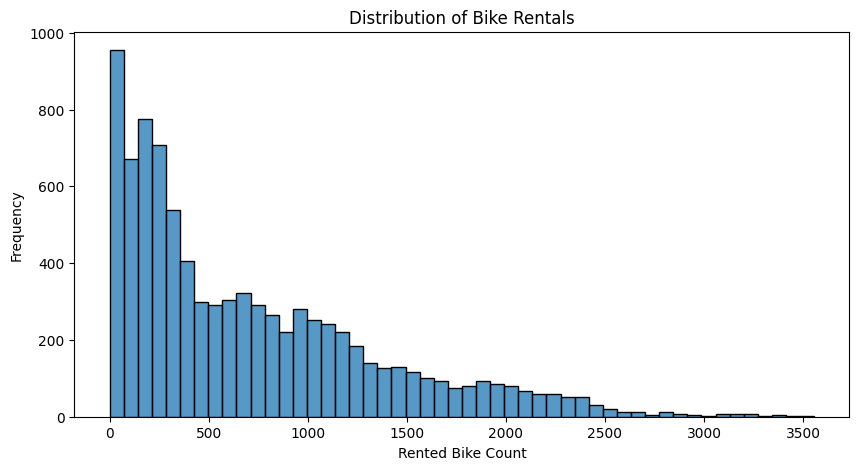

In [7]:
plt.figure(figsize=(10,5))

sns.histplot(df["Rented Bike Count"], bins=50)

plt.title("Distribution of Bike Rentals")
plt.xlabel("Rented Bike Count")
plt.ylabel("Frequency")

plt.show()

In [9]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 52892 (\N{HANGUL SYLLABLE KAELS}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52892 (\N{HANGUL SYLLABLE KAELS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


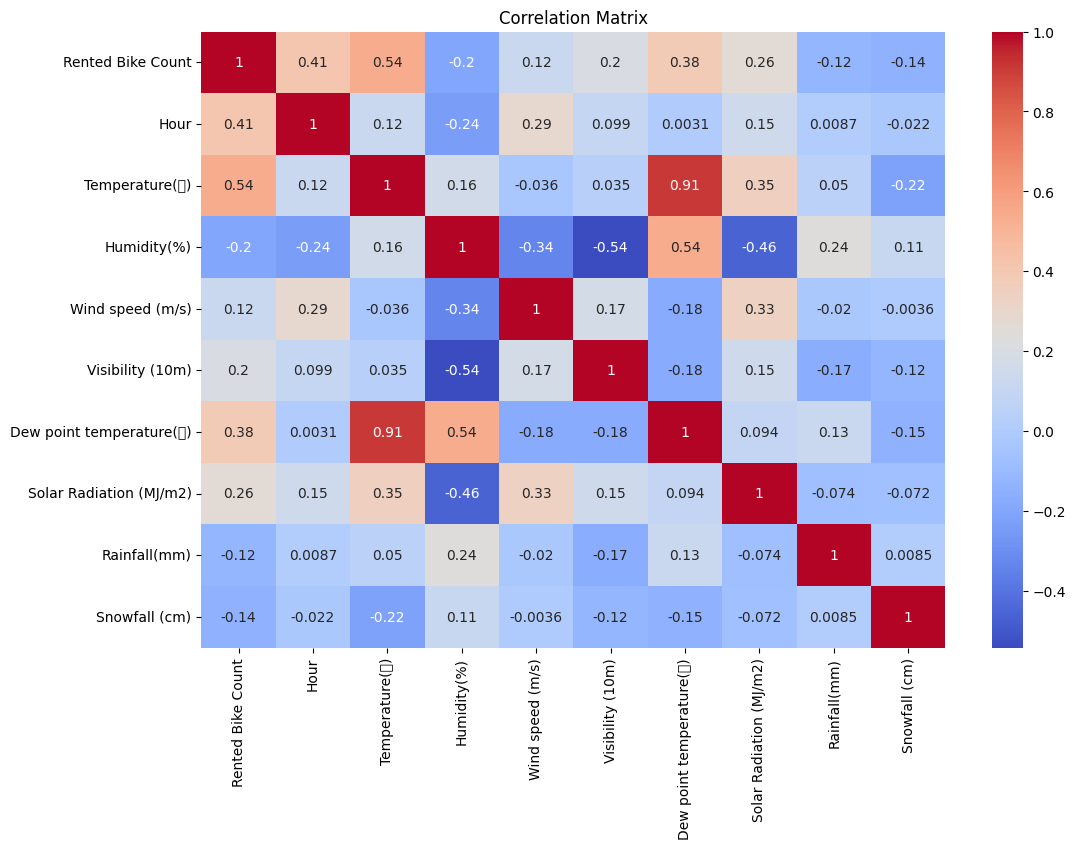

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [11]:
features = [
    "Hour",
    "Temperature(°C)",
    "Humidity(%)",
    "Wind speed (m/s)",
    "Visibility (10m)",
    "Dew point temperature(°C)",
    "Solar Radiation (MJ/m2)",
    "Rainfall(mm)",
    "Snowfall (cm)"
]

In [12]:
target = "Rented Bike Count"

In [13]:
X = df[features]
y = df[target]

KeyError: "['Temperature(°C)', 'Dew point temperature(°C)'] not in index"

In [14]:
df_encoded = pd.get_dummies(
    df,
    columns=["Seasons", "Holiday", "Functioning Day"],
    drop_first=True
)

In [15]:
df_encoded.head()

,Date,Rented Bike Count,Hour,Temperature(캜),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(캜),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons_Spring,Seasons_Summer,Seasons_Winter,Holiday_No Holiday,Functioning Day_Yes
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,False,False,True,True,True
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,False,False,True,True,True
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,False,False,True,True,True
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,False,False,True,True,True
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,False,False,True,True,True


In [17]:
X = df_encoded.drop(
    columns=["Rented Bike Count", "Date"]
)

y = df_encoded["Rented Bike Count"]

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
model_lr = LinearRegression()

model_lr.fit(X_train, y_train)

LinearRegression()

In [20]:
y_pred_lr = model_lr.predict(X_test)

In [21]:
mae = mean_absolute_error(y_test, y_pred_lr)

print("MAE:", mae)

MAE: 330.3852177498273


In [22]:
rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

print("RMSE:", rmse)

RMSE: 440.7813575261591


In [23]:
rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

print("RMSE:", rmse)

RMSE: 440.7813575261591
